# [[5,1,3]] Code Data Generation - Self-Contained

Fully self-contained implementation for syndrome data generation.
No local imports required - only reads the network graph pickle file.

**Protocol:**
1. Encode logical qubit at source using [[5,1,3]] code
2. SWAP encoded state along multi-hop path to sink
3. Measure syndrome at sink

No corrections applied - just raw syndrome observation.

In [1]:
# =============================================================================
# IMPORTS (External packages only)
# =============================================================================
from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.visualization import plot_histogram

import numpy as np
import networkx as nx
import pickle
import os
from typing import Dict, List, Tuple
from itertools import combinations

## Qubit Mapping Constants

Physical qubit mapping for 8-node fully connected network with [[5,1,3]] code.

- **Node qubits**: 9 per node (5 data + 4 ancilla) = 72 qubits
- **Path qubits**: 1 per edge = 28 qubits (C(8,2) edges)
- **Total**: 100 qubits

In [2]:
# =============================================================================
# QUBIT MAPPING CONSTANTS
# =============================================================================

# Node qubits: 9 per node (5 data + 4 ancilla)
NODE_PHYSICAL_QUBITS_513: Dict[int, List[int]] = {
    0: list(range(0, 9)),      # Node 0 → physical qubits 0-8
    1: list(range(9, 18)),     # Node 1 → physical qubits 9-17
    2: list(range(18, 27)),    # Node 2 → physical qubits 18-26
    3: list(range(27, 36)),    # Node 3 → physical qubits 27-35
    4: list(range(36, 45)),    # Node 4 → physical qubits 36-44
    5: list(range(45, 54)),    # Node 5 → physical qubits 45-53
    6: list(range(54, 63)),    # Node 6 → physical qubits 54-62
    7: list(range(63, 72)),    # Node 7 → physical qubits 63-71
}

# Path qubits: 1 per edge for SWAP transport
# All 28 edges of a fully connected 8-node graph
PATH_PHYSICAL_QUBITS_513: Dict[Tuple[int, int], List[int]] = {
    # Node 0 edges
    (0, 1): [72],
    (0, 2): [73],
    (0, 3): [74],
    (0, 4): [75],
    (0, 5): [76],
    (0, 6): [77],
    (0, 7): [78],
    # Node 1 edges (excluding 0-1)
    (1, 2): [79],
    (1, 3): [80],
    (1, 4): [81],
    (1, 5): [82],
    (1, 6): [83],
    (1, 7): [84],
    # Node 2 edges (excluding 0-2, 1-2)
    (2, 3): [85],
    (2, 4): [86],
    (2, 5): [87],
    (2, 6): [88],
    (2, 7): [89],
    # Node 3 edges (excluding 0-3, 1-3, 2-3)
    (3, 4): [90],
    (3, 5): [91],
    (3, 6): [92],
    (3, 7): [93],
    # Node 4 edges (excluding all above)
    (4, 5): [94],
    (4, 6): [95],
    (4, 7): [96],
    # Node 5 edges (excluding all above)
    (5, 6): [97],
    (5, 7): [98],
    # Node 6 edges (excluding all above)
    (6, 7): [99],
}

# Total qubits: 72 (nodes) + 28 (paths) = 100
TOTAL_QUBITS_513: int = 100

# [[5,1,3]] Stabilizer generators
STABILIZERS_513 = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]

print(f"Qubit mapping: {len(NODE_PHYSICAL_QUBITS_513)} nodes, {len(PATH_PHYSICAL_QUBITS_513)} edges")
print(f"Total qubits: {TOTAL_QUBITS_513}")

Qubit mapping: 8 nodes, 28 edges
Total qubits: 100


## Helper Functions

In [3]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def get_edge_key(node_a: int, node_b: int) -> Tuple[int, int]:
    """Get canonical edge key (smaller node first)."""
    return (min(node_a, node_b), max(node_a, node_b))


def get_node_qubits_513(node_id: int) -> Dict[str, List[int]]:
    """
    Get qubit indices for a node with named access.

    Returns:
        Dictionary with keys 'data' (5 qubits) and 'ancilla' (4 qubits)
    """
    if node_id not in NODE_PHYSICAL_QUBITS_513:
        raise ValueError(f"Invalid node_id: {node_id}. Valid: 0-{len(NODE_PHYSICAL_QUBITS_513)-1}")

    qubits = NODE_PHYSICAL_QUBITS_513[node_id]
    return {
        'data': qubits[0:5],
        'ancilla': qubits[5:9],
    }


def get_path_qubits_513(node_a: int, node_b: int) -> List[int]:
    """Get path qubit(s) for an edge (SWAP-based transport)."""
    edge_key = get_edge_key(node_a, node_b)
    if edge_key not in PATH_PHYSICAL_QUBITS_513:
        raise ValueError(f"No path defined for edge {edge_key}")
    return PATH_PHYSICAL_QUBITS_513[edge_key]


def print_qubit_mapping_513() -> None:
    """Print the qubit mapping for SWAP-based transport."""
    print("=" * 60)
    print("[[5,1,3]] Code Physical Qubit Mapping (SWAP-based)")
    print("=" * 60)

    print("\nNode Qubits (9 per node: 5 data + 4 ancilla):")
    print("-" * 40)
    for node, qubits in NODE_PHYSICAL_QUBITS_513.items():
        print(f"  Node {node}: qubits {qubits[0]:2d}-{qubits[-1]:2d} "
              f"(data={qubits[0]}-{qubits[4]}, ancilla={qubits[5]}-{qubits[8]})")

    print("\nPath Qubits (1 per edge):")
    print("-" * 40)
    for edge, qubits in PATH_PHYSICAL_QUBITS_513.items():
        print(f"  Edge {edge}: qubit(s) {qubits}")

    print(f"\nTotal qubits: {TOTAL_QUBITS_513}")
    print("=" * 60)

## [[5,1,3]] Code Functions

In [4]:
# =============================================================================
# [[5,1,3]] CODE FUNCTIONS
# =============================================================================

def apply_encoding_513(qc: QuantumCircuit, qubits: List[int]) -> None:
    """
    Apply [[5,1,3]] encoding circuit.

    Encodes a single logical qubit (on qubit[4]) into the 5-qubit code.
    Qubits 0-3 should be initialized to |0⟩ before encoding.

    Args:
        qc: QuantumCircuit to add gates to
        qubits: List of 5 qubit indices [q0, q1, q2, q3, q4] where q4 is the data qubit
    """
    if len(qubits) != 5:
        raise ValueError(f"Expected 5 qubits, got {len(qubits)}")

    qc.h(qubits[0])
    qc.z(qubits[0])
    qc.cz(qubits[0], qubits[4])
    qc.cx(qubits[0], qubits[4])

    qc.h(qubits[1])
    qc.cx(qubits[1], qubits[4])

    qc.h(qubits[2])
    qc.cx(qubits[2], qubits[4])
    qc.cz(qubits[2], qubits[1])
    qc.cz(qubits[2], qubits[0])

    qc.h(qubits[3])
    qc.z(qubits[3])
    qc.cz(qubits[3], qubits[4])
    qc.cx(qubits[3], qubits[4])
    qc.cz(qubits[3], qubits[2])
    qc.cz(qubits[3], qubits[0])


def apply_syndrome_measurement_513(
    qc: QuantumCircuit,
    data_qubits: List[int],
    ancilla_qubits: List[int],
    classical_bits,
    reset_ancillas: bool = True
) -> None:
    """
    Extract syndrome and measure ancilla qubits.

    Args:
        qc: QuantumCircuit to add gates to
        data_qubits: List of 5 data qubit indices [q0, q1, q2, q3, q4]
        ancilla_qubits: List of 4 ancilla qubit indices [a0, a1, a2, a3]
        classical_bits: ClassicalRegister or list of 4 classical bit indices
        reset_ancillas: If True, reset ancillas to |0⟩ before extraction
    """
    if len(data_qubits) != 5:
        raise ValueError(f"Expected 5 data qubits, got {len(data_qubits)}")
    if len(ancilla_qubits) != 4:
        raise ValueError(f"Expected 4 ancilla qubits, got {len(ancilla_qubits)}")

    if reset_ancillas:
        for ancilla in ancilla_qubits:
            qc.reset(ancilla)

    for idx, stabilizer in enumerate(STABILIZERS_513):
        ancilla = ancilla_qubits[idx]
        qc.h(ancilla)

        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(ancilla, data_qubits[qubit_idx])
            elif pauli == 'Z':
                qc.cz(ancilla, data_qubits[qubit_idx])

        qc.h(ancilla)
        qc.measure(ancilla, classical_bits[idx])


def apply_swap_along_edge(qc: QuantumCircuit, source_qubits: List[int], 
                          sink_qubits: List[int], path_qubits: List[int]) -> None:
    """SWAP all 5 code qubits from source to sink via path qubits."""
    num_path_qubits = len(path_qubits)
    for i in range(5):
        qc.swap(source_qubits[i], path_qubits[0])
        for j in range(num_path_qubits - 1):
            qc.swap(path_qubits[j], path_qubits[j + 1])
        qc.swap(path_qubits[num_path_qubits - 1], sink_qubits[i])

## Data Container Class

In [5]:
# =============================================================================
# DATA CONTAINER CLASS
# =============================================================================

class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        Container for syndrome measurement results.
        
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

## Configuration

In [6]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Experiment parameters
MAX_HOPS = 3
MIN_HOPS = 2
NUM_SHOTS = 4096
OPTIMIZATION_LEVEL = 1

# Paths - UPDATE THESE FOR YOUR SETUP
# NETWORK_GRAPH_PATH = '../networkgraphs/fully_connected_6_node.pkl'  # Path to network graph
NETWORK_GRAPH_PATH = '../networkgraphs/2x3_grid_network_graph.pkl'  # Path to network graph
# NUM_NODES = int(NETWORK_GRAPH_PATH.split('_')[-2])  # Extract number of nodes from filename
# OUTPUT_DIR = f'../pickle_files/fcn_{NUM_NODES}_node_513/'
OUTPUT_DIR = '../pickle_files/syndrome_data_513/'

# Basis gates for FakeFez
BASIS_GATES = ['cz', 'id', 'rz', 'sx', 'x']

print(f"Configuration:")
print(f"  Hops: {MIN_HOPS}-{MAX_HOPS}")
print(f"  Shots: {NUM_SHOTS}")
print(f"  Total qubits available: {TOTAL_QUBITS_513}")
print(f"  Network graph: {NETWORK_GRAPH_PATH}")
print(f"  Output directory: {OUTPUT_DIR}")

Configuration:
  Hops: 2-3
  Shots: 4096
  Total qubits available: 100
  Network graph: ../networkgraphs/2x3_grid_network_graph.pkl
  Output directory: ../pickle_files/syndrome_data_513/


In [7]:
# Display qubit mapping
print_qubit_mapping_513()

[[5,1,3]] Code Physical Qubit Mapping (SWAP-based)

Node Qubits (9 per node: 5 data + 4 ancilla):
----------------------------------------
  Node 0: qubits  0- 8 (data=0-4, ancilla=5-8)
  Node 1: qubits  9-17 (data=9-13, ancilla=14-17)
  Node 2: qubits 18-26 (data=18-22, ancilla=23-26)
  Node 3: qubits 27-35 (data=27-31, ancilla=32-35)
  Node 4: qubits 36-44 (data=36-40, ancilla=41-44)
  Node 5: qubits 45-53 (data=45-49, ancilla=50-53)
  Node 6: qubits 54-62 (data=54-58, ancilla=59-62)
  Node 7: qubits 63-71 (data=63-67, ancilla=68-71)

Path Qubits (1 per edge):
----------------------------------------
  Edge (0, 1): qubit(s) [72]
  Edge (0, 2): qubit(s) [73]
  Edge (0, 3): qubit(s) [74]
  Edge (0, 4): qubit(s) [75]
  Edge (0, 5): qubit(s) [76]
  Edge (0, 6): qubit(s) [77]
  Edge (0, 7): qubit(s) [78]
  Edge (1, 2): qubit(s) [79]
  Edge (1, 3): qubit(s) [80]
  Edge (1, 4): qubit(s) [81]
  Edge (1, 5): qubit(s) [82]
  Edge (1, 6): qubit(s) [83]
  Edge (1, 7): qubit(s) [84]
  Edge (2, 3)

## Noise Model

In [8]:
# =============================================================================
# NOISE MODEL
# =============================================================================
# Custom noise model:
# 1. Copy 1Q errors from FakeFez (per-qubit depolarizing, realistic rates)
# 2. Add custom 2Q depolarizing errors for all qubit pairs (all-to-all connectivity)

from qiskit_aer.noise import depolarizing_error

fake_backend = FakeFez()
target = fake_backend.target

noise_model = NoiseModel()

# --- 1. Copy 1Q errors from FakeFez ---
gates_to_copy = ['sx', 'x', 'rz', 'id']
copied_1q_count = 0

for gate in gates_to_copy:
    if gate not in target.operation_names:
        continue
    for qargs in target.qargs_for_operation_name(gate):
        props = target[gate][qargs]
        if props and props.error and props.error > 0:
            error = depolarizing_error(props.error, 1)
            noise_model.add_quantum_error(error, gate, list(qargs))
            copied_1q_count += 1

# --- 2. Add custom 2Q depolarizing errors for all qubit pairs ---
ERROR_RATE_2Q = 0.01  # 1% error for two-qubit gates
error_2q = depolarizing_error(ERROR_RATE_2Q, 2)

for i in range(TOTAL_QUBITS_513):
    for j in range(i + 1, TOTAL_QUBITS_513):
        noise_model.add_quantum_error(error_2q, 'cx', [i, j])
        noise_model.add_quantum_error(error_2q, 'cx', [j, i])
        noise_model.add_quantum_error(error_2q, 'cz', [i, j])
        noise_model.add_quantum_error(error_2q, 'cz', [j, i])

print(f"Backend reference: {fake_backend.name} ({fake_backend.num_qubits} qubits)")
print(f"1Q errors copied: {copied_1q_count} entries (from FakeFez)")
print(f"2Q error rate: {ERROR_RATE_2Q} (custom, all-to-all)")
print(f"Circuit qubits: {TOTAL_QUBITS_513}")
print(f"Transpilation basis gates: {BASIS_GATES}")

Backend: fake_fez (156 qubits)
Noise model basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
Transpilation basis gates: ['cz', 'id', 'rz', 'sx', 'x']


## Load Network

Network nodes: [0, 1, 2, 3, 4, 5]
Network edges: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]


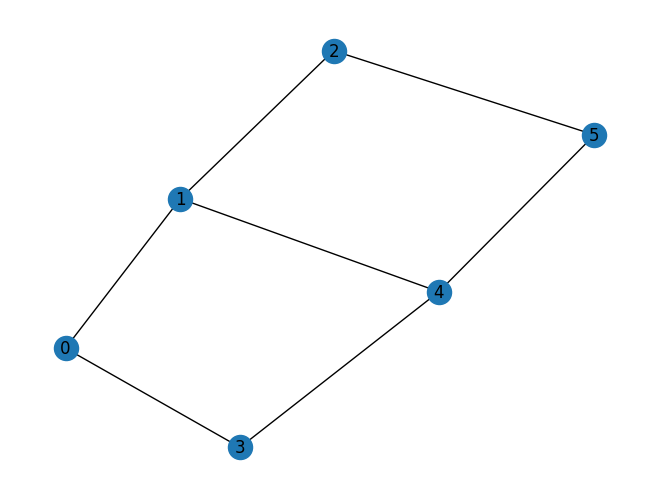

In [9]:
# =============================================================================
# LOAD NETWORK GRAPH
# =============================================================================

with open(NETWORK_GRAPH_PATH, 'rb') as f:
    network_graph = pickle.load(f)

print(f"Network nodes: {list(network_graph.nodes())}")
print(f"Network edges: {list(network_graph.edges())}")
nx.draw(network_graph, with_labels=True)

In [10]:
# =============================================================================
# GENERATE ALL MULTI-HOP PATHS
# =============================================================================

ALL_PATHS = []
for pair in combinations(network_graph.nodes, 2):
    paths = nx.all_simple_paths(network_graph, source=pair[0], target=pair[1], cutoff=MAX_HOPS)
    ALL_PATHS.extend([p for p in paths if len(p) > MIN_HOPS])

print(f"Total paths ({MIN_HOPS}-{MAX_HOPS} hops): {len(ALL_PATHS)}")
print(f"Sample: {ALL_PATHS[:3]}")

Total paths (2-3 hops): 24
Sample: [[0, 3, 4, 1], [0, 1, 2], [0, 1, 4, 3]]


## Circuit Builder

In [11]:
# =============================================================================
# CIRCUIT BUILDER
# =============================================================================

def build_513_swap_circuit(path: list, initial_state: str = '0') -> QuantumCircuit:
    """
    Build a [[5,1,3]] encode-swap-syndrome circuit.
    
    Protocol:
        1. Encode logical qubit at source
        2. SWAP along path to sink
        3. Measure syndrome at sink
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2]
        initial_state: '0' or '1'
    
    Returns:
        QuantumCircuit with syndrome measurement
    """
    source = path[0]
    sink = path[-1]
    
    # Get qubit assignments
    source_qubits = get_node_qubits_513(source)
    sink_qubits = get_node_qubits_513(sink)
    
    # Create circuit
    qc = QuantumCircuit(TOTAL_QUBITS_513)
    syndrome_reg = ClassicalRegister(4, name=f'syndrome_{sink}')
    qc.add_register(syndrome_reg)
    
    # ===================
    # 1. ENCODE AT SOURCE
    # ===================
    if initial_state == '1':
        qc.x(source_qubits['data'][4])  # Logical qubit is index 4
    
    apply_encoding_513(qc, source_qubits['data'])
    qc.barrier(label='Encode')
    
    # ===================
    # 2. SWAP ALONG PATH
    # ===================
    for i in range(len(path) - 1):
        src_node = path[i]
        dst_node = path[i + 1]
        
        src_data = get_node_qubits_513(src_node)['data']
        dst_data = get_node_qubits_513(dst_node)['data']
        path_qubits = get_path_qubits_513(src_node, dst_node)
        
        apply_swap_along_edge(qc, src_data, dst_data, path_qubits)
    
    qc.barrier(label='Swap')
    
    # ===================
    # 3. SYNDROME AT SINK
    # ===================
    apply_syndrome_measurement_513(
        qc,
        sink_qubits['data'],
        sink_qubits['ancilla'],
        syndrome_reg
    )
    
    return qc

## Test Circuit

In [12]:
# =============================================================================
# TEST CIRCUIT
# =============================================================================

test_path = [0, 1, 2]
test_circuit = build_513_swap_circuit(test_path, initial_state='0')

print(f"Path: {test_path}")
print(f"Qubits: {test_circuit.num_qubits}")
print(f"Classical bits: {test_circuit.num_clbits}")
print(f"Gate counts: {test_circuit.count_ops()}")

Path: [0, 1, 2]
Qubits: 100
Classical bits: 4
Gate counts: OrderedDict({'swap': 20, 'cz': 14, 'h': 12, 'cx': 12, 'reset': 4, 'measure': 4, 'z': 2, 'barrier': 2})


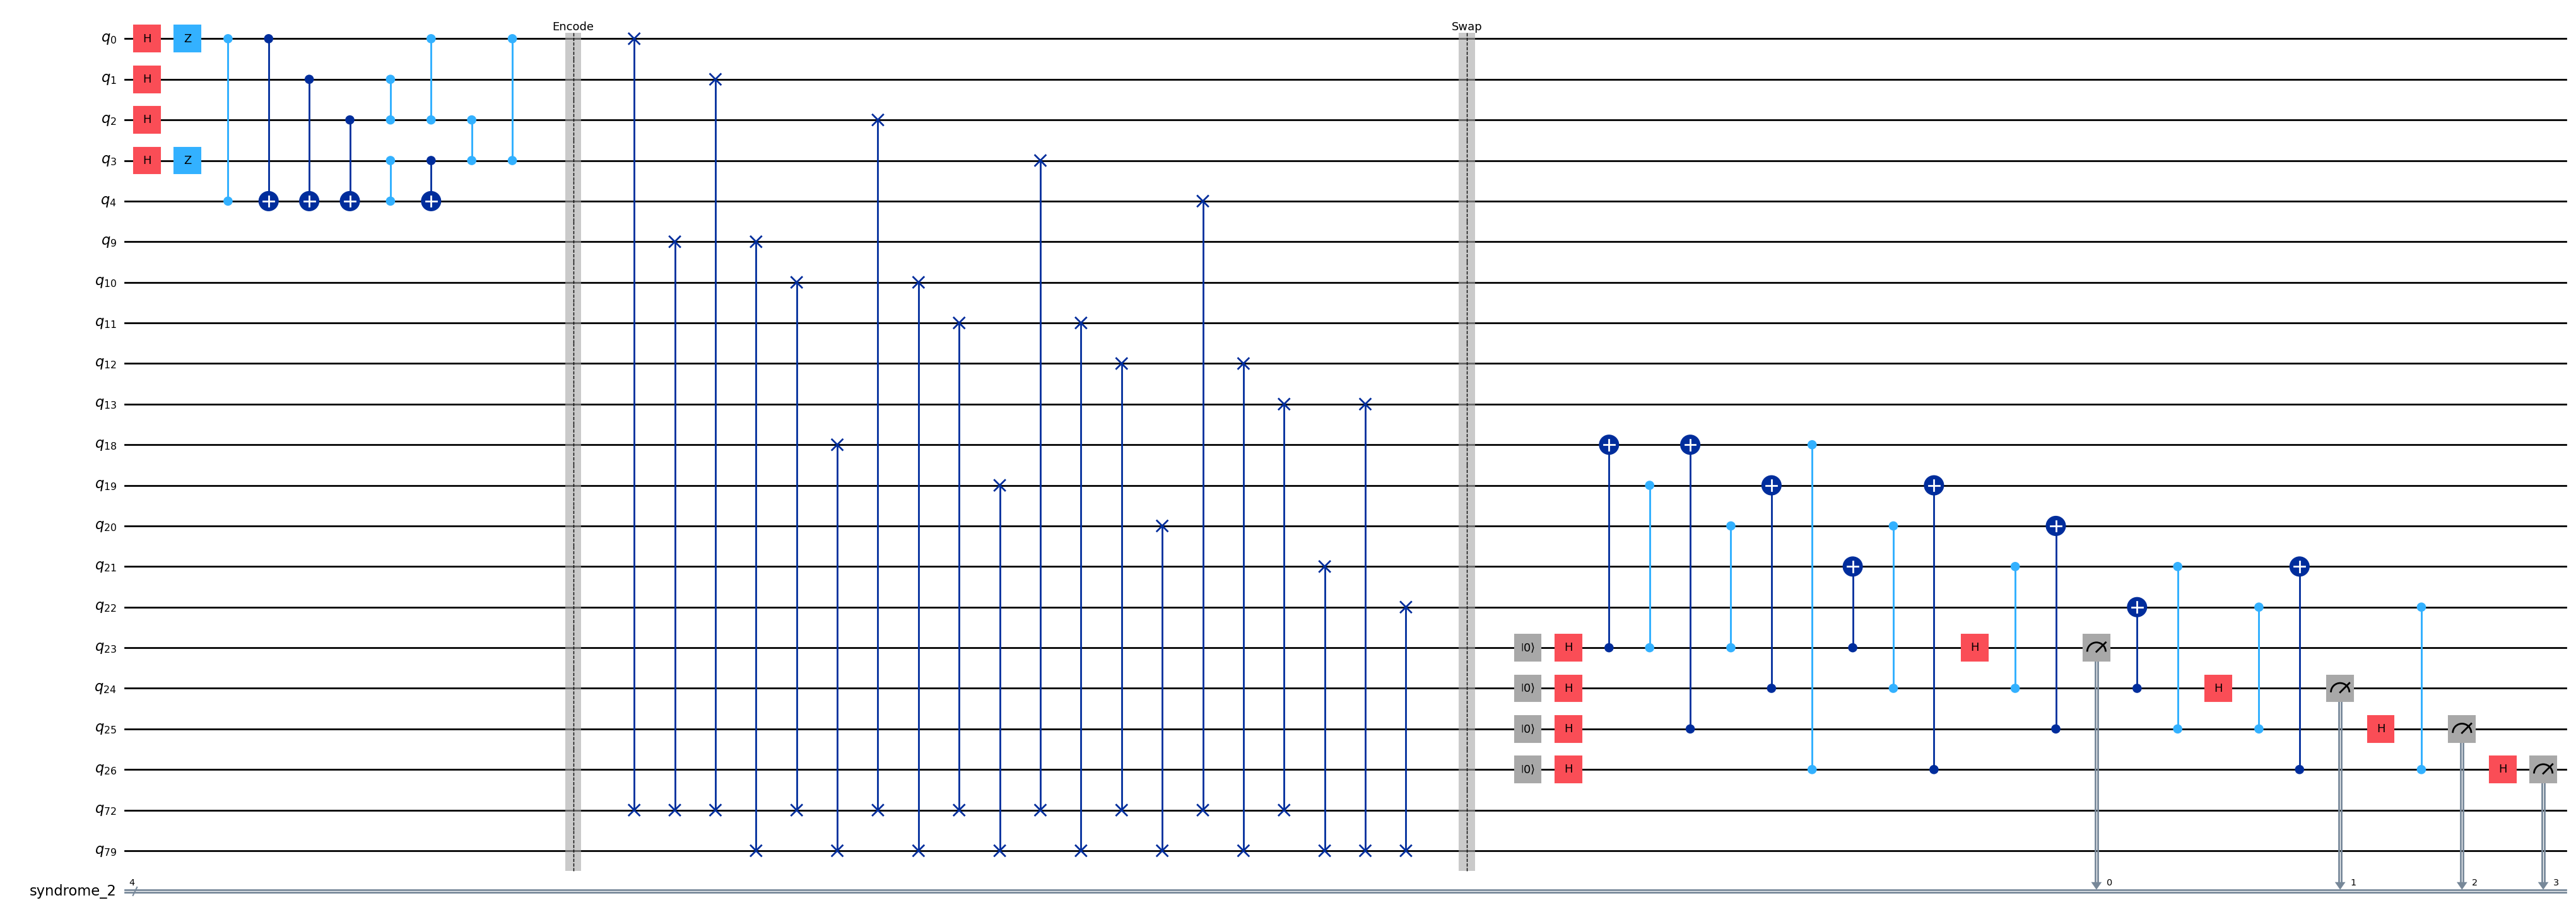

In [13]:
test_circuit.draw('mpl', fold=-1, idle_wires=False)

Noiseless syndrome counts: {'0000': 4096}


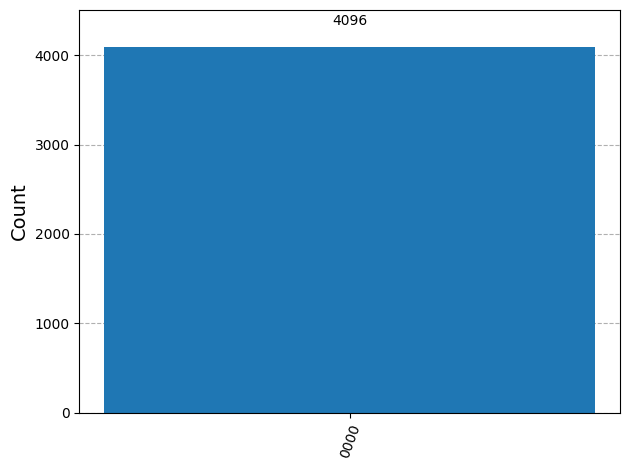

In [14]:
# =============================================================================
# NOISELESS SIMULATION
# =============================================================================

simulator = AerSimulator(method='matrix_product_state')
transpiled = transpile(test_circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)

result = simulator.run(transpiled, shots=NUM_SHOTS).result()
counts = result.get_counts()

print(f"Noiseless syndrome counts: {counts}")
plot_histogram(counts)

Noisy syndrome counts:
{'0000': 3874, '0001': 9, '0010': 12, '0011': 8, '0100': 16, '0101': 29, '0110': 9, '0111': 9, '1000': 17, '1001': 27, '1010': 18, '1011': 15, '1100': 14, '1101': 10, '1110': 17, '1111': 12}


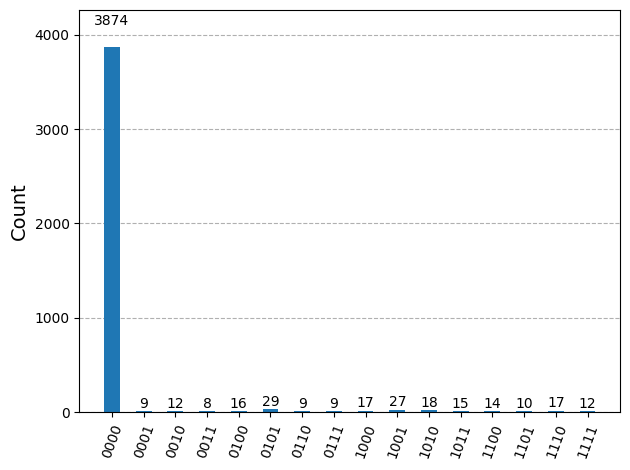

In [15]:
# =============================================================================
# NOISY SIMULATION
# =============================================================================

noisy_simulator = AerSimulator(noise_model=noise_model, method='matrix_product_state')

noisy_result = noisy_simulator.run(transpiled, shots=NUM_SHOTS).result()
noisy_counts = noisy_result.get_counts()

print("Noisy syndrome counts:")
print(dict(sorted(noisy_counts.items())))
plot_histogram(noisy_counts)

## Data Generation

In [16]:
# =============================================================================
# DATA GENERATION
# =============================================================================

# Setup simulator
noisy_sim = AerSimulator(noise_model=noise_model, method='matrix_product_state')

measurements = []

print("=" * 60)
print("[[5,1,3]] SYNDROME DATA GENERATION")
print("=" * 60)
print(f"Paths to process: {len(ALL_PATHS)}")
print("=" * 60)

for idx, path in enumerate(ALL_PATHS):
    print(f"\n[{idx+1}/{len(ALL_PATHS)}] Path: {path}")
    
    # Build and transpile
    circuit = build_513_swap_circuit(path, initial_state='0')
    transpiled = transpile(circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    
    # Run
    result = noisy_sim.run(transpiled, shots=NUM_SHOTS).result()
    counts = result.get_counts()
    
    # Build histogram - entries ordered by syndrome value (0000, 0001, 0010, ..., 1111)
    histogram = np.array(
        [counts.get(f"{i:04b}", 0) for i in range(16)],
        dtype=np.float32
    )
    
    # Store
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    measurements.append(
        TimeAwareMeasurement(path_edges, histogram, duration=0.0, latency_stats={}, code_type='513'))
    
    no_error_frac = histogram[0] / histogram.sum()
    print(f"  Edges: {path_edges}")
    print(f"  No-error fraction: {no_error_frac:.4f}")

print(f"\n{'=' * 60}")
print(f"Total measurements: {len(measurements)}")
print(f"{'=' * 60}")

[[5,1,3]] SYNDROME DATA GENERATION
Paths to process: 24

[1/24] Path: [0, 3, 4, 1]
  Edges: [(0, 3), (3, 4), (4, 1)]
  No-error fraction: 0.9229

[2/24] Path: [0, 1, 2]
  Edges: [(0, 1), (1, 2)]
  No-error fraction: 0.9485

[3/24] Path: [0, 1, 4, 3]
  Edges: [(0, 1), (1, 4), (4, 3)]
  No-error fraction: 0.9253

[4/24] Path: [0, 1, 4]
  Edges: [(0, 1), (1, 4)]
  No-error fraction: 0.9399

[5/24] Path: [0, 3, 4]
  Edges: [(0, 3), (3, 4)]
  No-error fraction: 0.9390

[6/24] Path: [0, 1, 2, 5]
  Edges: [(0, 1), (1, 2), (2, 5)]
  No-error fraction: 0.9329

[7/24] Path: [0, 1, 4, 5]
  Edges: [(0, 1), (1, 4), (4, 5)]
  No-error fraction: 0.8911

[8/24] Path: [0, 3, 4, 5]
  Edges: [(0, 3), (3, 4), (4, 5)]
  No-error fraction: 0.9011

[9/24] Path: [1, 4, 5, 2]
  Edges: [(1, 4), (4, 5), (5, 2)]
  No-error fraction: 0.9072

[10/24] Path: [1, 0, 3]
  Edges: [(1, 0), (0, 3)]
  No-error fraction: 0.9468

[11/24] Path: [1, 4, 3]
  Edges: [(1, 4), (4, 3)]
  No-error fraction: 0.9365

[12/24] Path: [1,

## Ground Truth

In [17]:
# =============================================================================
# GROUND TRUTH CIRCUIT (SWAP-based transport)
# =============================================================================

def build_ground_truth_circuit(source, sink, initial_state='0', measurement_basis='Z'):
    """
    Build a ground truth circuit for single-qubit transport using SWAP chains.
    
    This circuit transports a SINGLE (unencoded) qubit from source to sink
    and measures in the specified basis to determine error rates.
    
    Protocol:
        1. Prepare qubit at source in measurement_basis
        2. SWAP through path qubits to sink
        3. Rotate back to Z-basis and measure
    
    Args:
        source: Source node ID
        sink: Sink node ID
        initial_state: '0' or '1'
        measurement_basis: 'X', 'Y', or 'Z'
    
    Returns:
        QuantumCircuit with measurement
    """
    # Get physical qubit indices
    source_qubits = NODE_PHYSICAL_QUBITS_513[source]
    sink_qubits = NODE_PHYSICAL_QUBITS_513[sink]
    
    # Get path qubit(s) for this edge
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS_513[edge_key]
    
    # Create circuit
    qc = QuantumCircuit(TOTAL_QUBITS_513)
    
    # Data qubit is at index 4 within each node's allocation
    source_qubit = source_qubits[4]
    sink_qubit = sink_qubits[4]
    
    # Prepare initial state
    if initial_state == '1':
        qc.x(source_qubit)

    # Rotate to measurement basis if needed
    if measurement_basis == 'X':
        qc.h(source_qubit)
    elif measurement_basis == 'Y':
        qc.h(source_qubit)        
        qc.s(source_qubit)

    # Swapping path from source to sink
    num_path_qubits = len(path_qubits)
    qc.swap(source_qubit, path_qubits[0])
    for j in range(num_path_qubits - 1):
        qc.swap(path_qubits[j], path_qubits[j + 1])
    qc.swap(path_qubits[num_path_qubits - 1], sink_qubit)
    
    # Add classical register for measurement
    creg = ClassicalRegister(1, name='c_data')
    qc.add_register(creg)

    # Rotate back before measurement
    if measurement_basis == 'X':
        qc.h(sink_qubit)
    elif measurement_basis == 'Y':
        qc.sdg(sink_qubit)
        qc.h(sink_qubit)    

    qc.measure(sink_qubit, creg[0])

    return qc


def calculate_exact_pauli_rates(z_basis_counts, x_basis_counts, y_basis_counts, expected_state='0'):
    """
    Calculate exact Pauli error rates from three-basis measurements.
    
    For a qubit prepared in |0⟩ and measured in three bases:
    - Z-basis error (measure '1'): X or Y error occurred
    - X-basis error (measure '1'): Z or Y error occurred  
    - Y-basis error (measure '1'): X or Z error occurred
    
    Solving the system:
        E_z = p_x + p_y
        E_x = p_y + p_z
        E_y = p_x + p_z
    
    Gives:
        p_x = (E_z + E_y - E_x) / 2
        p_y = (E_z + E_x - E_y) / 2
        p_z = (E_x + E_y - E_z) / 2
    
    Args:
        z_basis_counts: {'0': n0, '1': n1} from Z-basis measurement
        x_basis_counts: {'0': n0, '1': n1} from X-basis measurement
        y_basis_counts: {'0': n0, '1': n1} from Y-basis measurement
        expected_state: '0' or '1' - the state we prepared
    
    Returns:
        dict with keys 'p_x', 'p_y', 'p_z', 'E_x', 'E_y', 'E_z'
    """
    error_outcome = '1' if expected_state == '0' else '0'
    
    total_z = sum(z_basis_counts.values())
    total_x = sum(x_basis_counts.values())
    total_y = sum(y_basis_counts.values())
    
    E_z = z_basis_counts.get(error_outcome, 0) / total_z
    E_x = x_basis_counts.get(error_outcome, 0) / total_x
    E_y = y_basis_counts.get(error_outcome, 0) / total_y
    
    # Solve for individual Pauli error rates
    p_x = max(0, (E_z + E_y - E_x) / 2)
    p_y = max(0, (E_z + E_x - E_y) / 2)
    p_z = max(0, (E_x + E_y - E_z) / 2)
    
    return {
        'p_x': p_x,
        'p_y': p_y,
        'p_z': p_z,
        'E_x': E_x,
        'E_y': E_y,
        'E_z': E_z
    }

In [18]:
# =============================================================================
# GROUND TRUTH DATA GENERATION
# =============================================================================
# Generate Pauli error rates for each edge using SWAP-based transport

GROUND_TRUTH_DATA = {}

print("=" * 70)
print("GROUND TRUTH DATA GENERATION (SWAP-based)")
print("=" * 70)
print(f"Using SWAP transport protocol with basis gate decomposition")
print(f"Basis gates: {BASIS_GATES}")
print(f"Edges to process: {list(network_graph.edges())}")
print("=" * 70)

for edge in network_graph.edges():
    print(f"\nEdge {edge}:")
    print(f"  Source qubits: {NODE_PHYSICAL_QUBITS_513[edge[0]][0]}-{NODE_PHYSICAL_QUBITS_513[edge[0]][-1]}")
    print(f"  Sink qubits: {NODE_PHYSICAL_QUBITS_513[edge[1]][0]}-{NODE_PHYSICAL_QUBITS_513[edge[1]][-1]}")
    
    # Build circuits using physical qubit mapping
    circuit_Z = build_ground_truth_circuit(edge[0], edge[1], measurement_basis='Z')
    circuit_X = build_ground_truth_circuit(edge[0], edge[1], measurement_basis='X')
    circuit_Y = build_ground_truth_circuit(edge[0], edge[1], measurement_basis='Y')

    # Transpile to basis gates for proper noise application
    decomposed_Z = transpile(circuit_Z, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    decomposed_X = transpile(circuit_X, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    decomposed_Y = transpile(circuit_Y, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)

    print("  Running Z-basis measurement...", end=' | ')
    counts_Z = dict(sorted(noisy_sim.run(decomposed_Z, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running X-basis measurement...", end=' | ')
    counts_X = dict(sorted(noisy_sim.run(decomposed_X, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running Y-basis measurement...")
    counts_Y = dict(sorted(noisy_sim.run(decomposed_Y, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))

    error_rates = calculate_exact_pauli_rates(
        z_basis_counts=counts_Z,
        x_basis_counts=counts_X,
        y_basis_counts=counts_Y,
        expected_state='0'
    )

    GROUND_TRUTH_DATA[edge] = [error_rates['p_x'], error_rates['p_y'], error_rates['p_z']]
    print(f"  Pauli Errors: PX={error_rates['p_x']:.6f}, PY={error_rates['p_y']:.6f}, PZ={error_rates['p_z']:.6f}")
    print(f"  Raw error rates: E_x={error_rates['E_x']:.6f}, E_y={error_rates['E_y']:.6f}, E_z={error_rates['E_z']:.6f}")

print(f"\n{'=' * 70}")
print("Ground truth data collection complete")
print(f"{'=' * 70}")

GROUND TRUTH DATA GENERATION (SWAP-based)
Using SWAP transport protocol with basis gate decomposition
Basis gates: ['cz', 'id', 'rz', 'sx', 'x']
Edges to process: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]

Edge (0, 1):
  Source qubits: 0-8
  Sink qubits: 9-17
  Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
  Pauli Errors: PX=0.000244, PY=0.000488, PZ=0.000732
  Raw error rates: E_x=0.001221, E_y=0.000977, E_z=0.000732

Edge (0, 3):
  Source qubits: 0-8
  Sink qubits: 27-35
  Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
  Pauli Errors: PX=0.000000, PY=0.001465, PZ=0.001953
  Raw error rates: E_x=0.003418, E_y=0.001709, E_z=0.001221

Edge (1, 2):
  Source qubits: 9-17
  Sink qubits: 18-26
  Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
  Pauli Errors: PX=0.000000, PY=0.001221, PZ=0.001465
  Raw error rates: E_x=0.002686, 

## Save Data

In [19]:
# =============================================================================
# SAVE DATA
# =============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(os.path.join(OUTPUT_DIR, 'measurements.pkl'), 'wb') as f:
    pickle.dump(measurements, f)

with open(os.path.join(OUTPUT_DIR, 'graph.pkl'), 'wb') as f:
    pickle.dump(network_graph, f)

with open(os.path.join(OUTPUT_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(GROUND_TRUTH_DATA, f)

print(f"Data saved to {OUTPUT_DIR}")
print(f"  - measurements.pkl ({len(measurements)} measurements)")
print(f"  - graph.pkl")
print(f"  - ground_truth.pkl ({len(GROUND_TRUTH_DATA)} edges)")
print(f"\nGround truth summary:")
for edge, rates in GROUND_TRUTH_DATA.items():
    print(f"  Edge {edge}: PX={rates[0]:.6f}, PY={rates[1]:.6f}, PZ={rates[2]:.6f}")

Data saved to ../pickle_files/syndrome_data_513/
  - measurements.pkl (24 measurements)
  - graph.pkl
  - ground_truth.pkl (7 edges)

Ground truth summary:
  Edge (0, 1): PX=0.000244, PY=0.000488, PZ=0.000732
  Edge (0, 3): PX=0.000000, PY=0.001465, PZ=0.001953
  Edge (1, 2): PX=0.000000, PY=0.001221, PZ=0.001465
  Edge (1, 4): PX=0.000000, PY=0.002930, PZ=0.000488
  Edge (2, 5): PX=0.001221, PY=0.002197, PZ=0.000000
  Edge (3, 4): PX=0.000244, PY=0.001221, PZ=0.002197
  Edge (4, 5): PX=0.000122, PY=0.005005, PZ=0.005493


## Analysis Summary

In [20]:
# =============================================================================
# ANALYSIS SUMMARY
# =============================================================================

# Find paths with low no-error fraction
print("\n" + "=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)

no_error_fractions = [(m.path_edges, m.histogram[0] / m.histogram.sum()) for m in measurements]
no_error_fractions.sort(key=lambda x: x[1])

print("\nTop 10 lowest no-error fraction paths:")
print("-" * 40)
for edges, frac in no_error_fractions[:10]:
    print(f"  {edges}: {frac:.4f}")

print("\nTop 10 highest no-error fraction paths:")
print("-" * 40)
for edges, frac in no_error_fractions[-10:]:
    print(f"  {edges}: {frac:.4f}")

# Check for paths below threshold
threshold = 0.8
low_performance = [(edges, frac) for edges, frac in no_error_fractions if frac < threshold]
print(f"\nPaths with no-error fraction < {threshold}: {len(low_performance)}")
for edges, frac in low_performance:
    print(f"  {edges}: {frac:.4f}")


ANALYSIS SUMMARY

Top 10 lowest no-error fraction paths:
----------------------------------------
  [(0, 1), (1, 4), (4, 5)]: 0.8911
  [(2, 5), (5, 4), (4, 3)]: 0.9001
  [(0, 3), (3, 4), (4, 5)]: 0.9011
  [(3, 4), (4, 5)]: 0.9014
  [(2, 1), (1, 4), (4, 5)]: 0.9028
  [(1, 2), (2, 5), (5, 4)]: 0.9065
  [(1, 4), (4, 5), (5, 2)]: 0.9072
  [(3, 0), (0, 1), (1, 4)]: 0.9104
  [(1, 4), (4, 5)]: 0.9114
  [(2, 5), (5, 4)]: 0.9202

Top 10 highest no-error fraction paths:
----------------------------------------
  [(1, 0), (0, 3), (3, 4)]: 0.9343
  [(2, 1), (1, 0), (0, 3)]: 0.9351
  [(1, 4), (4, 3)]: 0.9365
  [(0, 3), (3, 4)]: 0.9390
  [(0, 1), (1, 4)]: 0.9399
  [(2, 1), (1, 4)]: 0.9419
  [(1, 2), (2, 5)]: 0.9443
  [(4, 1), (1, 2), (2, 5)]: 0.9443
  [(1, 0), (0, 3)]: 0.9468
  [(0, 1), (1, 2)]: 0.9485

Paths with no-error fraction < 0.8: 0
